# 15 ANOVA

Chapter 13 compared means using t-tests.

A two-sample t-test is appropriate when we want to compare **two groups**. But what if we have three or more groups?

This chapter introduces **Analysis of Variance (ANOVA)**.

Despite its name, ANOVA is fundamentally used to investigate differences among **group means**.

The central question is:

> **Are the differences between group means large relative to the variability within groups?**

## Learning Objectives

After completing this chapter, you will be able to:

- explain why repeated pairwise t-tests are problematic;
- formulate ANOVA hypotheses;
- distinguish between-group and within-group variability;
- understand the F-statistic;
- calculate a one-way ANOVA manually;
- perform one-way ANOVA with SciPy;
- interpret an ANOVA p-value correctly;
- understand why a significant ANOVA does not identify which groups differ;
- perform Tukey's HSD as a post-hoc comparison;
- calculate $\eta^2$ as an effect-size measure;
- recognize the main assumptions and limitations of one-way ANOVA.

## 1. From t-test to ANOVA

Suppose we want to compare three population means:

$$
\mu_A,\quad \mu_B,\quad \mu_C
$$

We could perform:

- A vs B
- A vs C
- B vs C

using three separate t-tests.

But as the number of groups increases, the number of pairwise comparisons increases quickly:

$$
\frac{k(k-1)}{2}
$$

More tests mean more opportunities for false-positive results.

ANOVA provides **one overall test** for the equality of multiple means.

## 2. Research Question

We have three fictional training methods:

- Method A
- Method B
- Method C

Each participant belongs to exactly one group.

The outcome is a quantitative assessment score.

We ask:

> **Do the population mean assessment scores differ among the three training methods?**

The null hypothesis is:

$$
H_0:\mu_A=\mu_B=\mu_C
$$

The alternative is:

$$
H_1:\text{Not all population means are equal}
$$

Notice that $H_1$ does **not** say that every mean differs from every other mean.

## 3. Dataset

`15_anova.csv` contains synthetic data for 93 fictional participants.

Columns:

- `participant_id`
- `training_method`
- `assessment_score`

The three groups are independent.

The data were generated only for educational purposes, with somewhat different population centers so that the ANOVA workflow can be studied clearly.

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

cwd = Path.cwd().resolve()
root = next((p for p in [cwd, *cwd.parents] if (p / "data").is_dir()), None)

if root is None:
    raise FileNotFoundError("Could not find project root containing data/.")

df = pd.read_csv(root / "data" / "15_anova.csv")
df.head()

,participant_id,training_method,assessment_score
0,Participant_001,Method_A,74.4
1,Participant_002,Method_A,63.7
2,Participant_003,Method_A,78.0
3,Participant_004,Method_A,79.5
4,Participant_005,Method_A,56.4


In [22]:
df.groupby("training_method")["assessment_score"].agg(
    ["count", "mean", "std", "min", "max"]
).round(2)

,count,mean,std,min,max
training_method,,,,,
Method_A,30,72.13,6.20,56.4,81.8
Method_B,32,76.34,6.75,62.5,93.1
Method_C,31,81.74,5.61,70.5,89.7


## 4. Visualize the Groups First

Before testing, inspect the distributions.

We are interested in both:

- differences in group centers;
- variability within each group.

ANOVA is built around the relationship between these two sources of variation.

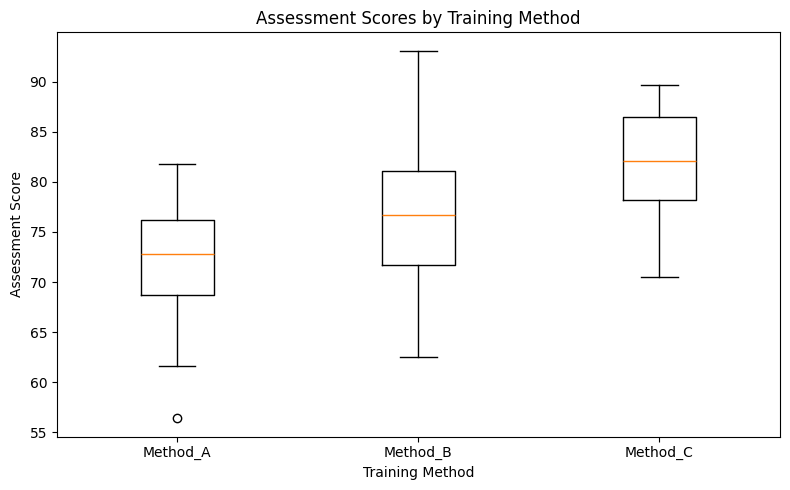

In [23]:
order = ["Method_A", "Method_B", "Method_C"]

group_values = [
    df.loc[df["training_method"] == group, "assessment_score"]
    for group in order
]

plt.figure(figsize=(8, 5))
plt.boxplot(group_values, tick_labels=order)
plt.title("Assessment Scores by Training Method")
plt.xlabel("Training Method")
plt.ylabel("Assessment Score")
plt.tight_layout()
plt.show()

# Part A — How ANOVA Works

## 5. Grand Mean and Group Means

Let:

$$
\bar{x}_j
$$

be the mean of group $j$, and:

$$
\bar{x}
$$

be the grand mean across all observations.

ANOVA asks how much the group means differ from the grand mean relative to the variability of observations within their own groups.

In [24]:
grand_mean = df["assessment_score"].mean()
group_means = df.groupby("training_method")["assessment_score"].mean()

print(f"Grand mean = {grand_mean:.3f}")
print("\nGroup means:")
print(group_means.round(3))

Grand mean = 76.782

Group means:
training_method
Method_A    72.133
Method_B    76.338
Method_C    81.739
Name: assessment_score, dtype: float64


## 6. Total Variability

The total sum of squares is:

$$
SS_T
=
\sum_{i=1}^{N}(x_i-\bar{x})^2
$$

This represents the total variation in the outcome around the grand mean.

In [25]:
ss_total = ((df["assessment_score"] - grand_mean) ** 2).sum()
print(f"SS Total = {ss_total:.3f}")

SS Total = 4888.619


## 7. Between-Group Variability

The between-group sum of squares is:

$$
SS_B
=
\sum_{j=1}^{k}
n_j(\bar{x}_j-\bar{x})^2
$$

It measures how far the group means are from the grand mean.

Larger differences among group means produce a larger $SS_B$.

In [26]:
group_counts = df.groupby("training_method")["assessment_score"].count()

ss_between = sum(
    group_counts[group] * (group_means[group] - grand_mean) ** 2
    for group in order
)

print(f"SS Between = {ss_between:.3f}")

SS Between = 1416.264


## 8. Within-Group Variability

The within-group sum of squares is:

$$
SS_W
=
\sum_{j=1}^{k}
\sum_{i=1}^{n_j}
(x_{ij}-\bar{x}_j)^2
$$

It measures variation among observations **inside** each group.

This is variation that is not explained simply by group membership.

In [27]:
ss_within = 0

for group in order:
    values = df.loc[
        df["training_method"] == group,
        "assessment_score"
    ]
    ss_within += ((values - values.mean()) ** 2).sum()

print(f"SS Within = {ss_within:.3f}")

SS Within = 3472.355


## 9. Variance Decomposition

A fundamental ANOVA identity is:

$$
SS_T = SS_B + SS_W
$$

In words:

$$
\text{Total Variation}
=
\text{Between-Group Variation}
+
\text{Within-Group Variation}
$$

In [28]:
print(f"SS Total             = {ss_total:.3f}")
print(f"SS Between + Within  = {(ss_between + ss_within):.3f}")
print(f"Difference           = {ss_total - (ss_between + ss_within):.10f}")

SS Total             = 4888.619
SS Between + Within  = 4888.619
Difference           = 0.0000000000


## 10. Degrees of Freedom

For one-way ANOVA:

### Between groups

$$
df_B=k-1
$$

### Within groups

$$
df_W=N-k
$$

### Total

$$
df_T=N-1
$$

and:

$$
df_T=df_B+df_W
$$

In [29]:
N = len(df)
k = df["training_method"].nunique()

df_between = k - 1
df_within = N - k
df_total = N - 1

print(f"N = {N}")
print(f"k = {k}")
print(f"df Between = {df_between}")
print(f"df Within  = {df_within}")
print(f"df Total   = {df_total}")

N = 93
k = 3
df Between = 2
df Within  = 90
df Total   = 92


## 11. Mean Squares

Sums of squares depend partly on the number of observations and groups.

We therefore divide them by their corresponding degrees of freedom.

### Between-group mean square

$$
MS_B=\frac{SS_B}{df_B}
$$

### Within-group mean square

$$
MS_W=\frac{SS_W}{df_W}
$$

In [30]:
ms_between = ss_between / df_between
ms_within = ss_within / df_within

print(f"MS Between = {ms_between:.3f}")
print(f"MS Within  = {ms_within:.3f}")

MS Between = 708.132
MS Within  = 38.582


## 12. The F-statistic

The ANOVA statistic is:

$$
F=
\frac{MS_B}{MS_W}
$$

Conceptually:

$$
F
=
\frac{\text{Variation Between Groups}}
{\text{Variation Within Groups}}
$$

If $H_0$ is true, we do not expect the between-group variation to be extremely large relative to within-group variation.

A sufficiently large $F$ provides evidence against equal population means.

In [31]:
f_manual = ms_between / ms_within

print(f"Manual F = {f_manual:.4f}")

Manual F = 18.3541


## 13. The F Distribution

Under the null model and ANOVA assumptions, the F-statistic follows an F distribution with:

$$
df_1=k-1
$$

and:

$$
df_2=N-k
$$

The ANOVA test is right-tailed because unusually **large** F values provide evidence against $H_0$.

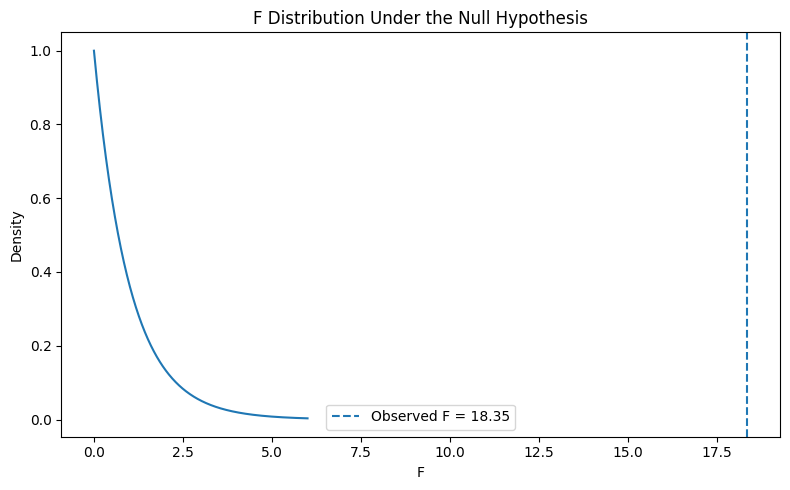

In [32]:
x = np.linspace(0, 6, 500)
y = stats.f.pdf(x, df_between, df_within)

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.axvline(f_manual, linestyle="--", label=f"Observed F = {f_manual:.2f}")
plt.title("F Distribution Under the Null Hypothesis")
plt.xlabel("F")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Part B — One-Way ANOVA with SciPy

## 14. Perform the Test

SciPy provides:

```python
stats.f_oneway(group1, group2, group3)
```

This performs the classical one-way ANOVA.

In [33]:
method_a = df.loc[df["training_method"] == "Method_A", "assessment_score"]
method_b = df.loc[df["training_method"] == "Method_B", "assessment_score"]
method_c = df.loc[df["training_method"] == "Method_C", "assessment_score"]

anova_result = stats.f_oneway(method_a, method_b, method_c)

print(f"F statistic = {anova_result.statistic:.4f}")
print(f"p-value     = {anova_result.pvalue:.6f}")

F statistic = 18.3541
p-value     = 0.000000


## 15. Decision

Using:

$$
\alpha=0.05
$$

- if $p<0.05$, reject $H_0$;
- otherwise, fail to reject $H_0$.

If we reject $H_0$, the appropriate conclusion is:

> There is evidence that **not all population means are equal**.

It would be incorrect to conclude from the overall ANOVA alone that:

> Every group differs significantly from every other group.

ANOVA is an **omnibus test**.

## 16. ANOVA Table

The calculations can be summarized in a standard ANOVA table.

| Source | Sum of Squares | df | Mean Square | F |
|---|---:|---:|---:|---:|
| Between | $SS_B$ | $k-1$ | $MS_B$ | $MS_B/MS_W$ |
| Within | $SS_W$ | $N-k$ | $MS_W$ | |
| Total | $SS_T$ | $N-1$ | | |

In [34]:
anova_table = pd.DataFrame({
    "Source": ["Between Groups", "Within Groups", "Total"],
    "SS": [ss_between, ss_within, ss_total],
    "df": [df_between, df_within, df_total],
    "MS": [ms_between, ms_within, np.nan],
    "F": [f_manual, np.nan, np.nan],
})

anova_table.round(3)

,Source,SS,df,MS,F
0,Between Groups,1416.264,2,708.132,18.354
1,Within Groups,3472.355,90,38.582,NaN
2,Total,4888.619,92,NaN,NaN


# Part C — Effect Size

## 17. Eta-Squared

A significant result does not tell us how much of the observed variation is associated with group membership.

A simple ANOVA effect-size measure is eta-squared:

$$
\eta^2
=
\frac{SS_B}{SS_T}
$$

It represents the proportion of total sample variation attributable to between-group differences in this one-way decomposition.

Its range is:

$$
0\leq\eta^2\leq1
$$

Interpret practical importance in context rather than relying only on generic thresholds.

In [35]:
eta_squared = ss_between / ss_total

print(f"Eta-squared = {eta_squared:.3f}")
print(f"Approx. proportion of sample variation associated with group differences = {eta_squared:.1%}")

Eta-squared = 0.290
Approx. proportion of sample variation associated with group differences = 29.0%


# Part D — Post-Hoc Comparisons

## 18. Why Post-Hoc Tests?

Suppose the overall ANOVA is significant.

We then know:

$$
\text{Not all means are equal}
$$

but we still do not know which pairs differ.

Possible comparisons are:

- A vs B
- A vs C
- B vs C

Running ordinary t-tests independently would reintroduce the multiple-comparison problem.

A post-hoc procedure controls the family-wise error rate across the set of pairwise comparisons.

## 19. Tukey's HSD

A common post-hoc procedure is **Tukey's Honestly Significant Difference (HSD)**.

SciPy provides `scipy.stats.tukey_hsd`.

We perform Tukey's HSD after the overall ANOVA to investigate pairwise differences while accounting for multiple comparisons.

In [36]:
tukey_result = stats.tukey_hsd(method_a, method_b, method_c)
print(tukey_result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -4.204     0.025    -7.966    -0.442
 (0 - 2)     -9.605     0.000   -13.396    -5.814
 (1 - 0)      4.204     0.025     0.442     7.966
 (1 - 2)     -5.401     0.002    -9.132    -1.671
 (2 - 0)      9.605     0.000     5.814    13.396
 (2 - 1)      5.401     0.002     1.671     9.132



## 20. Pairwise Interpretation

The order supplied to `tukey_hsd` was:

1. Method A
2. Method B
3. Method C

The output provides pairwise statistics and adjusted p-values.

Interpret the post-hoc results together with the group means.

A useful workflow is:

$$
\text{Overall ANOVA}
\rightarrow
\text{If warranted, Post-Hoc Comparisons}
\rightarrow
\text{Effect Size + Context}
$$

In [37]:
means = pd.Series({
    "Method_A": method_a.mean(),
    "Method_B": method_b.mean(),
    "Method_C": method_c.mean(),
})
means.round(2)

Method_A    72.13
Method_B    76.34
Method_C    81.74
dtype: float64

# Part E — Assumptions

## 21. Independence

Observations should be sufficiently independent according to the study design.

For example, if the same person appears in multiple groups, ordinary one-way independent-groups ANOVA is not appropriate.

Study design comes before the statistical test.

## 22. Normality

Classical one-way ANOVA assumes Normal errors within groups.

In practice, ANOVA can be reasonably robust to moderate non-Normality, particularly with adequate and reasonably balanced group sizes.

However:

- severe skewness;
- extreme outliers;
- very small samples

deserve careful attention.

Visual inspection should accompany formal analysis.

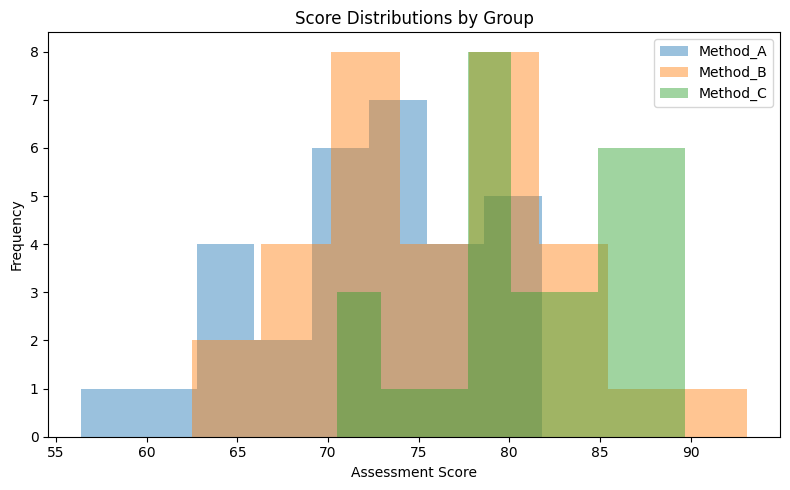

In [38]:
plt.figure(figsize=(8, 5))

for group in order:
    values = df.loc[df["training_method"] == group, "assessment_score"]
    plt.hist(values, bins=8, alpha=0.45, label=group)

plt.title("Score Distributions by Group")
plt.xlabel("Assessment Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Homogeneity of Variance

Classical one-way ANOVA assumes equal population variances:

$$
\sigma_A^2=\sigma_B^2=\sigma_C^2
$$

We should not treat a separate variance test as a mechanical gatekeeper, but descriptive spreads and diagnostics can help us understand the data.

For reference, Levene's test evaluates equality of variances:

$$
H_0:\sigma_A^2=\sigma_B^2=\sigma_C^2
$$

In [39]:
levene_result = stats.levene(method_a, method_b, method_c)

print(f"Levene statistic = {levene_result.statistic:.4f}")
print(f"p-value          = {levene_result.pvalue:.6f}")

Levene statistic = 0.2919
p-value          = 0.747522


## 24. What If Variances Differ?

The classical ANOVA introduced here assumes equal population variances.

When that assumption is questionable, **Welch's ANOVA** is an important alternative.

The conceptual connection is similar to Chapter 13:

- classical Student-style procedures use an equal-variance assumption;
- Welch-style procedures relax that assumption.

This chapter focuses on the classical one-way ANOVA framework because its variance decomposition makes the core logic especially clear.

Choosing alternatives should depend on the study design, sample sizes, distributions, and variance patterns—not on mechanically searching for the smallest p-value.

## 25. ANOVA Does Not Establish Causation

A significant ANOVA tells us that population means are not all equal under the model and design assumptions.

It does not automatically tell us **why** they differ.

If groups were randomly assigned in a well-designed experiment, causal interpretation may be more defensible.

With observational groups, confounding variables may explain the differences.

Statistical significance and causal inference are separate questions.

## 26. Connection to t-tests

For exactly two independent groups, classical one-way ANOVA and the equal-variance two-sample t-test are closely related:

$$
F=t^2
$$

when they are applied to the same two-group data under corresponding assumptions.

ANOVA is therefore not an unrelated technique—it generalizes the idea of comparing means to multiple groups.

In [40]:
two_group_anova = stats.f_oneway(method_a, method_b)
two_group_t = stats.ttest_ind(method_a, method_b, equal_var=True)

print(f"F              = {two_group_anova.statistic:.6f}")
print(f"t²             = {two_group_t.statistic ** 2:.6f}")
print(f"ANOVA p-value  = {two_group_anova.pvalue:.6f}")
print(f"t-test p-value = {two_group_t.pvalue:.6f}")

F              = 6.496744
t²             = 6.496744
ANOVA p-value  = 0.013383
t-test p-value = 0.013383


## Important Distinctions

### Between-Group vs Within-Group Variation
ANOVA compares variability among group means with variability inside groups.

### ANOVA vs Multiple t-tests
ANOVA provides one overall test and avoids using many unadjusted pairwise tests as the initial analysis.

### Overall Test vs Post-Hoc Test
A significant ANOVA says that not all means are equal. Post-hoc procedures investigate which pairs differ.

### p-value vs Effect Size
The p-value addresses evidence against equal means. $\eta^2$ describes the proportion of sample variation associated with the group factor.

### Association vs Causation
Different group means do not automatically imply that group membership caused the difference.

## Exercises

### Exercise 1
Calculate $SS_B$, $SS_W$, and $SS_T$ manually and confirm:

$$
SS_T=SS_B+SS_W
$$

### Exercise 2
Calculate $MS_B$, $MS_W$, and the F-statistic without using `stats.f_oneway`.

### Exercise 3
Confirm that your manual F-statistic matches SciPy.

### Exercise 4
Change Method C scores by subtracting 5 points. Re-run ANOVA and explain what changes.

### Exercise 5
Run Tukey's HSD and identify which pairs show evidence of different population means.

### Exercise 6
Calculate $\eta^2$ and explain what it represents.

### Exercise 7
Use only Method A and Method B. Confirm:

$$
F=t^2
$$

for classical one-way ANOVA and the equal-variance independent t-test.

### Exercise 8
Explain why three separate unadjusted t-tests are not equivalent to a well-planned ANOVA plus multiplicity-adjusted post-hoc analysis.

### Exercise 9
Describe the assumptions you would investigate before applying classical one-way ANOVA to real data.

### Exercise 10
Explain why a significant ANOVA does not prove that the training method caused the score differences.

## Summary

One-way ANOVA extends mean comparison from two groups to three or more independent groups.

Its central decomposition is:

$$
SS_T=SS_B+SS_W
$$

and its test statistic is:

$$
F=\frac{MS_B}{MS_W}
$$

The analysis flow is:

$$
\text{Research Design}
\rightarrow
H_0/H_1
\rightarrow
\text{Between vs Within Variation}
\rightarrow
F
\rightarrow
p
\rightarrow
\text{Post-Hoc}
\rightarrow
\text{Effect Size}
\rightarrow
\text{Interpretation}
$$

You learned:

- why ANOVA is needed;
- one-way ANOVA hypotheses;
- sums of squares;
- degrees of freedom;
- mean squares;
- the F-statistic and F distribution;
- SciPy one-way ANOVA;
- Tukey's HSD;
- eta-squared;
- major assumptions;
- the connection between ANOVA and t-tests.

> **ANOVA asks whether differences among group means are large relative to the variability observed within groups.**

This completes **Part 3 — Statistical Inference**.

Next:

# Part 4 — Relationship Between Variables

# 16 Covariance

We move from comparing groups to studying how **two quantitative variables vary together**.